# 3.5 概率与统计：把不确定性说清楚

> 3.0 基础课程：先直觉，再符号，再数字代入，再用代码和图形核对。

## Goal

理解事件、随机变量、Bernoulli/类别分布、联合/边缘/条件概率、独立性、链式法则、期望、方差、odds、likelihood、采样偏差与校准。

## Setup 与数据边界

本课不加载用户行为数据。代码中的小数组都是带标签的 **数学教学对象**，只用于验证公式，绝不冒充交互、曝光、标签或行为序列。

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
TEACHING_OBJECTS_ONLY = True
print({"project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "kind": "curriculum", "teaching_objects_only": True})

from matplotlib import font_manager

# Matplotlib 默认的 DejaVu Sans 不包含中文字形。优先选择容器中的 Noto CJK
# （镜像已安装 fonts-noto-cjk），其次是宿主机常见中文字体；从字体根源解决，
# 而不是用 warnings.filterwarnings 掩盖 missing glyph 警告。
cjk_candidates = ('Noto Sans CJK SC', 'Noto Sans CJK JP', 'PingFang SC', 'Hiragino Sans GB',
                  'Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'Songti SC')
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
cjk_font = next((name for name in cjk_candidates if name in installed_fonts), None)
if cjk_font:
    plt.rcParams['font.sans-serif'] = [cjk_font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('图表字体:', cjk_font or '未找到中文字体（请安装 fonts-noto-cjk）')

{'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'kind': 'curriculum', 'teaching_objects_only': True}
图表字体: Hiragino Sans GB


## 学习路径

从一次不确定事件开始；用随机变量给结果编码；用条件概率描述“已知什么”；再用期望和方差概括分布，最后区分概率、似然、采样偏差与校准。

## 符号表

| 符号 | 含义 |
|---|---|
| $P(A)$ | 事件 A 发生的概率 |
| $X$ | 取值不确定的随机变量 |
| $P(A\mid B)$ | 已知 B 后 A 的概率 |
| $E[X]$ | 长期平均值，即期望 |
| $Var(X)$ | 围绕期望的波动大小 |
| $p/(1-p)$ | odds，发生与不发生机会之比 |

> 所有抛硬币、类别和分数数组都是数学教学对象，不是交互数据。

<a id="random-variable"></a>
## 1. 事件、随机变量与分布

事件是可判断真假的集合，例如“点击”；随机变量把结果映射成数。Bernoulli 变量只取 0/1，参数 $p$；类别变量在多个互斥类别中取一个，所有类别概率和为 1。分布不是一串已经发生的数据，而是对可能结果及其概率的说明。

### 数字代入 1：Bernoulli

若 $P(X=1)=0.3$，则 $P(X=0)=0.7$。重复 10 次的期望成功数是 $10\times0.3=3$，但某次实际出现 2 或 5 次都不矛盾。

<a id="conditional-chain"></a>
## 2. 联合、边缘、条件、独立与概率链式法则

联合概率 $P(A,B)$ 描述两件事同时发生；边缘概率把另一变量的所有可能求和；条件概率 $P(A\mid B)=P(A,B)/P(B)$。独立要求 $P(A,B)=P(A)P(B)$，不是简单的“不相等”。链式法则为 $P(A,B)=P(A\mid B)P(B)$，序列可继续展开。

### 数字代入 2：条件与链式法则

100 个教学对象中 40 个满足 B，其中 10 个同时满足 A，则 $P(B)=0.4$、$P(A,B)=0.1$、$P(A\mid B)=10/40=0.25$；反乘 $0.25\times0.4=0.1$ 回到联合概率。

{'P(A)': [0.6, 0.4], 'P(B)': [0.7, 0.3], 'P(A=1|B=1)': np.float64(0.4)}


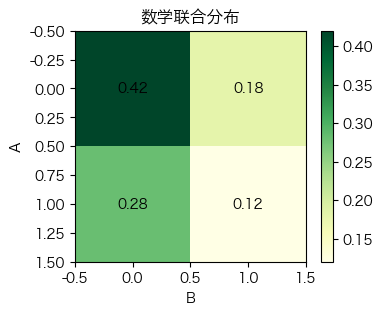

In [2]:
# Demo 1：从一个明确给定的数学联合分布求边缘与条件概率。
joint = np.array([[.42,.18], [.28,.12]])  # rows A=0/1, cols B=0/1；教学分布
p_a = joint.sum(axis=1); p_b = joint.sum(axis=0)
p_a1_given_b1 = joint[1,1] / p_b[1]
print({"P(A)": p_a.tolist(), "P(B)": p_b.tolist(), "P(A=1|B=1)": p_a1_given_b1})
fig, ax = plt.subplots(figsize=(4,3)); im=ax.imshow(joint,cmap="YlGn")
for r in range(2):
    for c in range(2): ax.text(c,r,f"{joint[r,c]:.2f}",ha="center",va="center")
ax.set(xlabel="B", ylabel="A", title="数学联合分布"); plt.colorbar(im); plt.show()

<a id="expectation-variance"></a>
## 3. 期望与方差

$E[X]=\sum_x xP(X=x)$ 是按概率加权的平均；$Var(X)=E[(X-E[X])^2]$ 先看每个值离均值多远，再平方加权。两组预测平均相同，方差可能完全不同。

### 数字代入 3：同均值不同波动

教学变量等概率取 $[1,3]$，期望为 2，方差为 $[(1-2)^2+(3-2)^2]/2=1$。若等概率取 $[-1,5]$，期望仍为 2，方差变为 9。

<a id="likelihood-calibration"></a>
## 4. odds、logit、似然、采样偏差与校准

概率 $p=0.8$ 的 odds 是 $0.8/0.2=4$，logit 为 $\log4\approx1.386$；意思是发生机会约为不发生的 4 倍。概率固定参数后问“数据会怎样”；似然固定观察数据后问“哪个参数更支持这些数据”。

采样偏差指样本来源改变了总体比例，例如只记录热门物品曝光。校准要求预测为 0.7 的一组样本中，长期约 70% 为正；排序很好不代表校准就好。

### 数字代入 4：似然与校准

观察教学标签 $[1,1,0]$。若 Bernoulli 参数 $p=0.8$，似然为 $0.8\times0.8\times0.2=0.128$；若 $p=0.5$，为 $0.125$。在这个很小样本里两者相近，不能过度下结论。若 10 个预测都为 0.7 而只有 4 个为正，经验正率 0.4 与 0.7 相差 0.3，提示未校准。

{'mean1': np.float64(2.0), 'var1': np.float64(1.0), 'mean2': np.float64(2.0), 'var2': np.float64(9.0)}


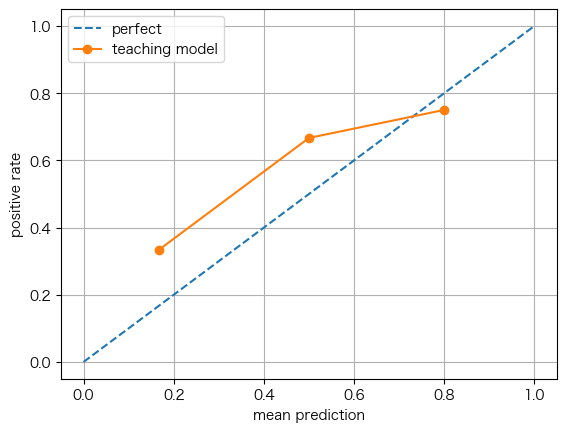

In [3]:
# Demo 2：期望/方差和一个简单可靠性图。
values1, values2 = np.array([1.,3.]), np.array([-1.,5.])
print({"mean1": values1.mean(), "var1": values1.var(),
       "mean2": values2.mean(), "var2": values2.var()})
pred = np.array([.1,.2,.2,.4,.5,.6,.7,.8,.8,.9])       # 教学预测
label = np.array([0,0,1,0,1,1,1,1,0,1])               # 教学标签
bins = np.array([0,.33,.66,1.01]); ids=np.digitize(pred,bins)-1
mean_pred=[pred[ids==i].mean() for i in range(3)]
rate=[label[ids==i].mean() for i in range(3)]
plt.plot([0,1],[0,1],"--",label="perfect"); plt.plot(mean_pred,rate,"o-",label="teaching model")
plt.xlabel("mean prediction"); plt.ylabel("positive rate"); plt.legend(); plt.grid(); plt.show()

## 常见误区

- 概率 0.7 意味着本次一定发生：它描述重复条件下的不确定性。
- $P(A\mid B)=P(B\mid A)$：分母不同，通常不相等。
- 不相关就等于独立：独立条件更强。
- 排序指标高就概率准确：AUC 与校准回答不同问题。

## 算法回链

- [GBDT+LR：logit 与点击概率](/notebooks/4_5_gbdt_lr)
- [DSSM：条件概率与负采样](/notebooks/5_2_dssm)
- [DIN：候选条件下的点击概率](/notebooks/6_3_din)
- [MMoE：多个 Bernoulli 任务](/notebooks/7_2_mmoe)
- [OpenOneRec：序列条件概率](/notebooks/8_2_openonerec_practice)

## Checks

1. 为什么 $P(A\mid B)$ 与 $P(B\mid A)$ 通常不同？
2. 期望相同是否代表风险相同？
3. 如何用一组 0.8 预测检查校准？

In [4]:
assert np.isclose(joint.sum(),1)
assert np.isclose(p_a1_given_b1*p_b[1], joint[1,1])
assert values1.mean()==values2.mean() and values1.var()<values2.var()
assert np.isclose((.8**2)*.2, .128)
print("PASS：联合/条件、期望/方差、似然计算检查通过。")

PASS：联合/条件、期望/方差、似然计算检查通过。


## Next Steps

下一课从信息量与熵出发，解释交叉熵、Softmax、序列 NLL 等概率损失为何以对数为共同语言。